# RXJ 1131 conmparison
This notebook compiles the TDCOSMO sample. It uses the 1d Ddt posteriors from the power-law models and re-processes the kinematics to allow for an explicit treatment of the kinematic assumptions in a hierarchical way.

The first part is to re-compute the kinematics to derive a covariance matrix to be used in the hierarchical analysis. The second part performs the hierarchical sampling of the mass profile and cosmological parameters for the TDCOSMO sample.

Requirements:
- lenstronomy (https://github.com/lenstronomy/lenstronomy)
- hierarc (https://github.com/sibirrer/hierArc)

Author: TDCOSMO collaboration



In [1]:
from hierarc.LensPosterior.ddt_kin_constraints import DdtKinConstraints
from hierarc.Sampling.mcmc_sampling import MCMCSampler
from lenstronomy.Analysis.light_profile import LightProfileAnalysis
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Util import param_util
import lenstronomy.Util.multi_gauss_expansion as mge
import corner
import emcee
import numpy as np
import pickle
import copy
import os
import csv
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import sklearn
from pylab import rc
rc('axes', linewidth=2)
rc('xtick',labelsize=15)
rc('ytick',labelsize=15)

#%load_ext autoreload
#%autoreload 2


In [2]:


# set relative paths to working directory and data
dir_path = os.getcwd()
path2processed = dir_path
base_path, _ = os.path.split(dir_path)

# file containing the meta-data of all the lenses (i.e. redshifts and marginal lens model parameter posteriors)
table_name = 'tdcosmo_sample.csv'
yaml_name = 'tdcosmo_sample.yaml'

table_file_path = os.path.join(dir_path, table_name)
yaml_file_path = os.path.join(dir_path, yaml_name)
path2posteriors = os.path.join(dir_path, 'TDCOSMO_data')


In [3]:
# numerical settings (not needed if power-law profiles with Hernquist light distribution is computed)
kwargs_numerics_galkin = {'interpol_grid_num': 1000,  # numerical interpolation, should converge -> infinity
                          'log_integration': True,  # log or linear interpolation of surface brightness and mass models
                           'max_integrate': 100, 'min_integrate': 0.001}  # lower/upper bound of numerical integrals

anisotropy_model = 'const'  # 'OM', 'GOM' or 'const'

# number of draws from the lens model posterior to compute the kinematics
num_sample_model = 200  # number of kinematics to be computed from the lensing posterior to compute the covariance matrix for a single slit observation (single Gaussian) 
num_sample_model_multi_obs = 500  # to calculate the covariance matrix between multiple observations, more samples are needed than for a single data point

In [4]:

def light_model_arguments(table, mge=True, light_model_type=None):
    """
    reads out the light model configuration
    :return: lens_light_model_list, kwargs_lens_light
    """
    if light_model_type is None:
        row = table
    else:
        row = table[light_model_type]
    light_model = str(row['light_model'])
    if light_model in ['single_sersic', 'double_sersic', 'triple_sersic']  or (light_model == 'mge' and not mge):
        r_sersic_1, n_sersic_1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1'])
        e1_1_light, e2_1_light = float(row['e1_sersic1']), float(row['e2_sersic1'])
        kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1, 'e1': e1_1_light, 'e2': e2_1_light, 'center_x': 0, 'center_y': 0}]
        lens_light_model_list=['SERSIC_ELLIPSE']
        if light_model in ['double_sersic', 'triple_sersic']  or (light_model == 'mge' and not mge):
            r_sersic_2, n_sersic_2, amp_sersic_2 = float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['amp_sersic_2'])
            e1_2_light, e2_2_light = float(row['e1_sersic2']), float(row['e2_sersic2'])
            kwargs_lens_light.append({'R_sersic': r_sersic_2, 'amp': amp_sersic_2, 'n_sersic': n_sersic_2, 'e1': e1_2_light, 'e2': e2_2_light, 'center_x': 0, 'center_y': 0})
            lens_light_model_list.append('SERSIC_ELLIPSE')
        if light_model in ['triple_sersic']  or (light_model == 'mge' and not mge):
            r_sersic_3, n_sersic_3, amp_sersic_3 = float(row['r_sersic_3']), float(row['n_sersic_3']), float(row['amp_sersic_3'])
            e1_3_light, e2_3_light = float(row['e1_sersic3']), float(row['e2_sersic3'])
            kwargs_lens_light.append({'R_sersic': r_sersic_3, 'amp': amp_sersic_3, 'n_sersic': n_sersic_3, 'e1': e1_3_light, 'e2': e2_3_light, 'center_x': 0, 'center_y': 0})
            lens_light_model_list.append('SERSIC_ELLIPSE')
        
    elif light_model == 'mge' and mge:
        kwargs_lens_light = [{"amp": row['amp'], "sigma": row["sigma"], 'center_x': 0, 'center_y': 0}]
        lens_light_model_list = ['MULTI_GAUSSIAN']
        
    else:
        r_eff = float(row['r_eff'])
        kwargs_lens_light = [{'Rs': r_eff * 0.551, 'amp': 1., 'center_x': 0, 'center_y': 0}]
        lens_light_model_list=['HERNQUIST']
    return lens_light_model_list, kwargs_lens_light, light_model



def light_model_config(row, light_model_type=None):
    """
    param row: list of keywords from the .csv file of the entry of a lens
    """
    # MGE light models if available
    

    lens_light_model_list, kwargs_lens_light, light_model = light_model_arguments(row, light_model_type=light_model_type)
    
    lightModel = LightModel(light_model_list=lens_light_model_list)
    lightAnalysis = LightProfileAnalysis(light_model=lightModel)
    try:
        r_eff = float(row['r_eff'])
    except:
        r_eff = lightAnalysis.half_light_radius(kwargs_light=kwargs_lens_light, grid_spacing=0.1, grid_num=200)
        print("newly calculated half light radius r_eff=  %s" % r_eff)
    
    lens_light_model_list_ell, kwargs_lens_light_ell, _ = light_model_arguments(row, mge=False, light_model_type=light_model_type)
    lightAnalysis_ell = LightProfileAnalysis(light_model=LightModel(light_model_list=lens_light_model_list_ell))
    e1, e2 = lightAnalysis_ell.ellipticity(kwargs_lens_light_ell, grid_spacing=0.1, grid_num=200)

    phi_light, q_light = param_util.ellipticity2phi_q(e1, e2)
    try:
        q_mass = float(row['q'])
    except:
        q_mass = 1
    phi_mass = 0
    if light_model in ['double_sersic', 'single_sersic']:
        MGE_light = True
        kwargs_mge_light = {'grid_spacing': r_eff/100., 'grid_num': 500, 'n_comp': 20, 'center_x': None, 'center_y': None}
    else:
        MGE_light = False
        kwargs_mge_light = None
    
    if MGE_light is True:
        r_array = np.logspace(-2.5, 2, 100)
        flux_r = lightAnalysis.radial_light_profile(r_array, kwargs_lens_light, center_x=0, center_y=0,
                                                     model_bool_list=None)

        amplitudes, sigmas, norm = mge.mge_1d(r_array, flux_r, N=20)
        # mge of light profile
        light_mge = LightModel(light_model_list=['MULTI_GAUSSIAN'])
        kwargs_light_mge = [{'amp': amplitudes, 'sigma': sigmas}]
        flux_r_mge = light_mge.surface_brightness(r_array, 0, kwargs_light_mge)
        
        plt.loglog(r_array, flux_r, '--', label='exact')
        plt.loglog(r_array, flux_r_mge, '-.', label='MGE')
        plt.ylim(0.000001, 100000)
        plt.legend()
        plt.show()
        kwargs_lens_light = kwargs_light_mge
        lens_light_model_list = ['MULTI_GAUSSIAN']
        MGE_light = False
        
    return lens_light_model_list, kwargs_lens_light, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff


def read_lens_dict(name, yaml_file=True):
    """
    get dictionary of all lens properties
    """
    if yaml_file:
        with open(yaml_file_path) as f:
            my_dict = yaml.safe_load(f)
            return my_dict[name]
    else:
        with open(table_file_path, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                name_lens = row['name']
                if name_lens == name:
                    return row
            raise ValueError("name %s not found in csv file." % name)


def process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model, yaml_file=True, vel_disp_name=None):
    """
    :param name: string, name of lens according to the csv file
    :param ddt_samples: numpy array, Ddt posteriors
    :param ddt_weights: numpy array or None, individual weights of the posteriors
    :param kappa_pdf: numpy array, probability density of p(kappa)
    :param kappa_bin_edges: numpy array, bin edges of kappa_pdf
    :param num_sample_model: integer, number of draws from the posterior to sample the kinematics prediction covariance matrix
    :param yaml_file: boolean, if True, read the lens properties from the yaml file
    :param vel_disp_name: string, name of the velocity dispersion measurement to use for lenses with multiple measurements
    """
    row = read_lens_dict(name, yaml_file=yaml_file)
    lens_light_model_list, kwargs_lens_light, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff = light_model_config(row)
                    
    kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                    'r_eff': r_eff, 'r_eff_error': float(row['r_eff_error']),
                    'theta_E': float(row['theta_E']), 'theta_E_error': float(row['theta_E_error']),
                    'gamma': float(row['gamma']), 'gamma_error': float(row['gamma_error'])}
    
    if vel_disp_name is not None:
        vel_disp_dict = row[vel_disp_name]
    else:
        vel_disp_dict = row
    if "aperture_radius" in vel_disp_dict:
        kwargs_aperture = {'aperture_type': 'shell', 'r_out': float(vel_disp_dict['aperture_radius']), 'r_in': 0, 'center_ra': 0.0, 'center_dec': 0}
    else:
        kwargs_aperture = {'aperture_type': 'slit', 'length': float(vel_disp_dict['slit_length']), 'width': float(vel_disp_dict['slit_width']), 'center_ra': 0.0, 'center_dec': 0, 'angle': 0}
    if "moffat_beta" in vel_disp_dict:
        kwargs_seeing = {'psf_type': 'MOFFAT', 'fwhm': float(vel_disp_dict['psf_fwhm']), 
                         'moffat_beta': float(vel_disp_dict['moffat_beta'])}
    else:
        kwargs_seeing = {'psf_type': 'GAUSSIAN', 'fwhm': float(vel_disp_dict['psf_fwhm'])}

    sigma_v = [float(vel_disp_dict['sigma_v'])]
    sigma_v_error_independent = [float(vel_disp_dict['sigma_v_error'])]
                
    ddt_kin = DdtKinConstraints(ddt_samples=ddt_samples, ddt_weights=ddt_weights,
                                        sigma_v_measured=sigma_v, sigma_v_error_independent=sigma_v_error_independent, 
                                        sigma_v_error_covariant=0, hernquist_approx=False,
                            kwargs_aperture=kwargs_aperture, kwargs_seeing=kwargs_seeing, 
                            kwargs_numerics_galkin=kwargs_numerics_galkin, 
                            anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light, 
                            lens_light_model_list=lens_light_model_list, MGE_light=MGE_light,
                            kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=100, **kwargs)

    kwargs_posterior = ddt_kin.hierarchy_configuration(num_sample_model=num_sample_model)
    kwargs_posterior['name'] = name
    # add external convergence
    kwargs_posterior['kappa_pdf'] = kappa_pdf
    kwargs_posterior['kappa_bin_edges'] = kappa_bin_edges

    kwargs_posterior['kwargs_lens_properties'] = {'theta_E': float(row['theta_E']),
                                                    'gamma': float(row['gamma']),
                                                    'r_eff': r_eff,
                                                    'q_light': q_light, 'phi_light': phi_light,
                                                    'q_mass': q_mass, 'phi_mass': phi_mass}

    kwargs_posterior = dict(**kwargs_posterior, **{'kde_kernel':'gaussian', 'bandwidth':20, 'nbins_hist':100})
    return kwargs_posterior 

def properties(name, partial_name=True, yaml_file=True):
    """
    returns Einstein radius and half-light radius
    """
    if yaml_file:
        with open(yaml_file_path) as f:
            my_dict = yaml.safe_load(f)
            row = my_dict[name]
            theta_E = float(row['theta_E'])
            r_eff = float(row['r_eff'])
            return theta_E, r_eff
        
    else:
        with open(table_file_path, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                if (partial_name and name[:4] == str(row['name'])[:4]) or name == str(row['name']):
                    theta_E = float(row['theta_E'])
                    r_eff = float(row['r_eff'])
                    return theta_E, r_eff

## RXJ1131−1231

Discovery presented in [Sluse et al. 2003](https://ui.adsabs.harvard.edu/abs/2003A%26A...406L..43S/abstract)

HST imaging modeling presented in [Suyu et al. 2014](https://ui.adsabs.harvard.edu/abs/2014ApJ...788L..35S/abstract).
AO imaging modeling presented in [Chen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.490.1743C/abstract)


Velocity dispersion measurement from Keck-LRIS  presented in [Suyu et al. 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...766...70S/abstract)
withg $323 \pm 20$ km/s including systematics.


Time-delay measurement presented in [Tewes et al. 2012](https://ui.adsabs.harvard.edu/abs/2012Msngr.150...49T/abstract)

LOS analysis presented in [Suyu et al. 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...766...70S/abstract)

Independent re-analysis by [Birrer et al. 2016](https://ui.adsabs.harvard.edu/abs/2016JCAP...08..020B/abstract)

New KCWI data by [Shajib et al. 2023](https://ui.adsabs.harvard.edu/abs/2023A%26A...673A...9S/abstract)

JWST IFU data to be presented in Shajib et al. 2025. (in prep)

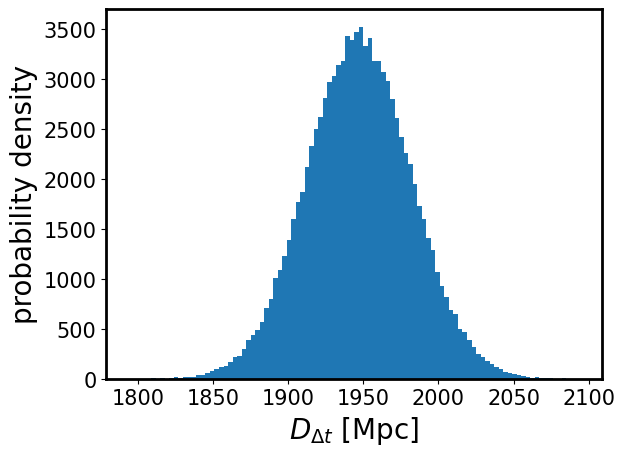

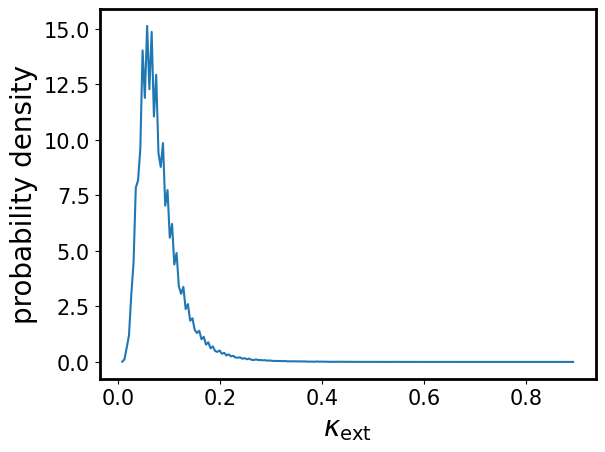

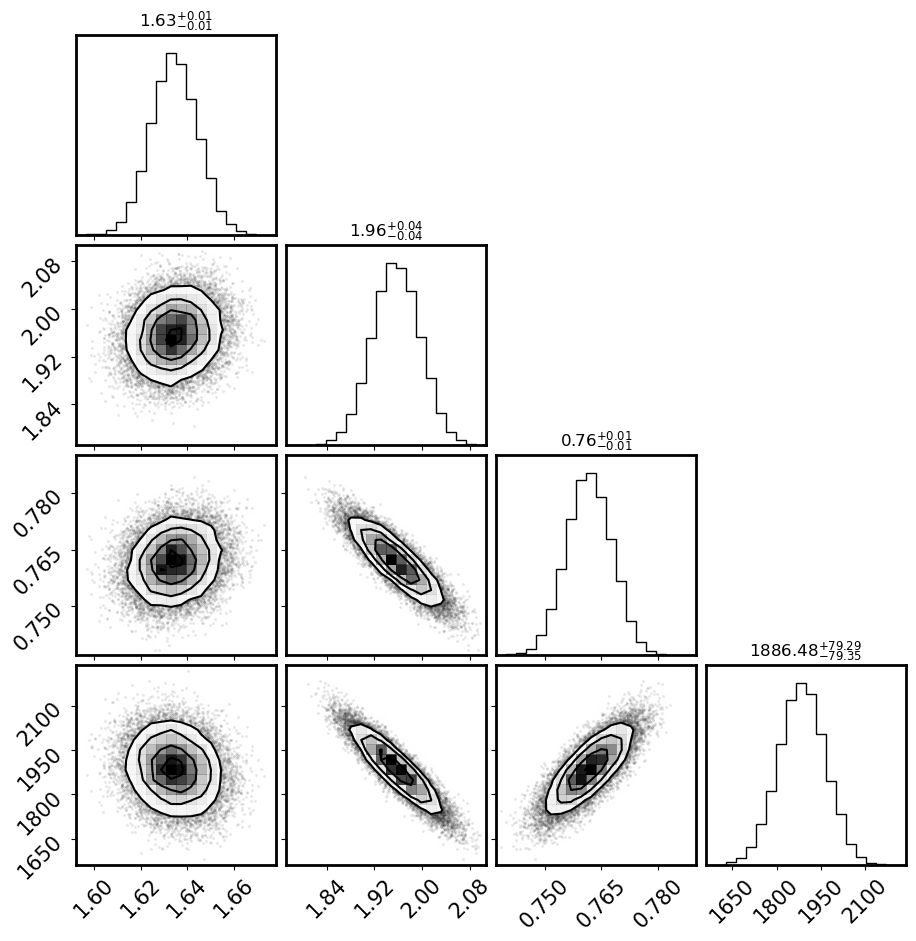

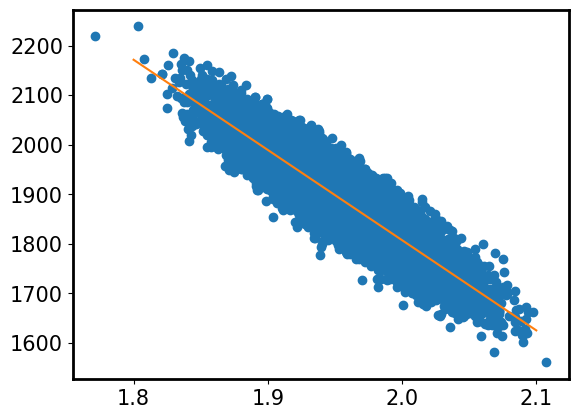

34.55727122057366 80.00690433343705


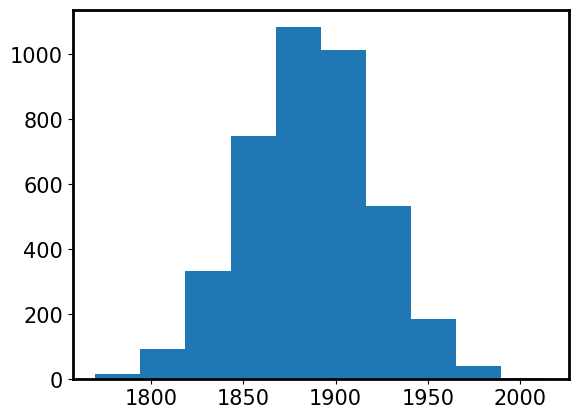

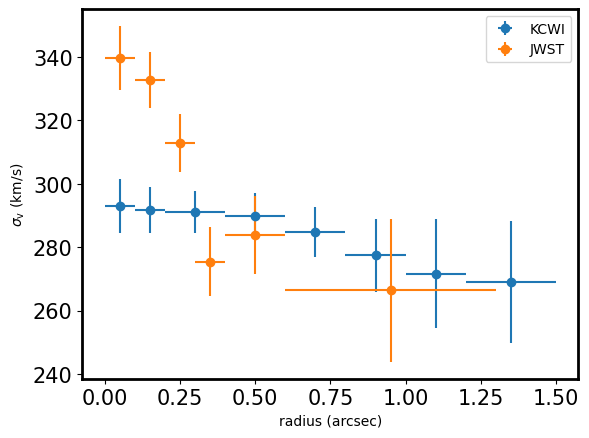

In [5]:
name = 'RXJ1131-1231'

reprocessing = False

ddt_posterior_file = 'rxj_powerlaw_Ddt.dat'
kappa_ext_file = 'kappa_powerlaw_rxj.dat'
ifu_kin_kcwi_file = 'rxj1131_kcwi_v_rms_binned.h5'
ifu_kin_jwst_file = 'rxj1131_jwst_v_rms_binned.h5'

path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)
path2ifukin_kcwi = os.path.join(path2posteriors, name, ifu_kin_kcwi_file)
path2ifukin_jwst = os.path.join(path2posteriors, name, ifu_kin_jwst_file)

# open ddt posterior
ddt_samples = np.loadtxt(path2ddt, delimiter=',', skiprows=1)
ddt_samples = np.random.choice(ddt_samples, size=100000)  # we select 100'000 posteriors to keep the memory requirement lower
ddt_weights = None
plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


# open kappa_ext posterior
kappa_sample = np.loadtxt(path2kappa, delimiter=',', skiprows=1)
kappa_weights = None


kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


# import posteriors
rxj_path = os.path.join(dir_path, 'TDCOSMO_data/RXJ1131-1231')
posterior_path = os.path.join(rxj_path, 'rxj1131_glee_power_law_lens_model_posterior.txt')

rxj_posteriors = np.loadtxt(posterior_path)

corner.corner(rxj_posteriors, show_titles=True)
plt.show()



# The `rxj1131_glee_power_law_lens_model_posterior.txt` file contains the weighted-combined power-law model chain for RXJ1131 from Suyu et al. (2013) (cf. black contours of Fig 3 therein). The columns are $\theta_{\rm E}$ [arcsec], $\gamma$, $q_{\rm m}$, and $D_{\Delta t}$ [Mpc] (without $\kappa_{\rm ext}$ incorporated).

#plot gamma_pl vs Ddt

gamma_pl = rxj_posteriors[:, 1]
ddt = rxj_posteriors[:, 3]
gamma_pl_mean = np.mean(gamma_pl)
ddt_mean = np.mean(ddt)
ddt_sigma = np.std(ddt)
gamma_pl_sigma = np.std(gamma_pl)

d2_posterior = np.vstack((gamma_pl, ddt))
cov = np.cov(d2_posterior)


x = np.linspace(start=1.8, stop=2.1, num=10)

gamma_pl_ddt_slope = cov[1, 0] / gamma_pl_sigma**2

y = (x - gamma_pl_mean) * gamma_pl_ddt_slope + ddt_mean

plt.plot(gamma_pl, ddt, 'o')
plt.plot(x, y, '-')

plt.show()


ddt_select = ddt[(gamma_pl > gamma_pl_mean - 0.01) & (gamma_pl < gamma_pl_mean + 0.01)]

ddt_select_std = np.std(ddt_select)
print(ddt_select_std, ddt_sigma)
plt.hist(ddt_select)
plt.show()





# open ifu kin values
import h5py as h5

with h5.File(path2ifukin_kcwi, 'r') as f:
    sigma_v_kcwi = f['binned_dispersion'][()]
    covariance_matrix_kcwi = f['covariance'][()]
    radial_bins_kcwi = f['radial_bins'][()]
    
plt.errorbar(x=(radial_bins_kcwi[:-1]+np.diff(radial_bins_kcwi)/2.), 
             y=sigma_v_kcwi, 
             xerr=np.diff(radial_bins_kcwi)/2.,
             yerr=np.sqrt(np.diag(covariance_matrix_kcwi)),
             ls='None', marker='o', label='KCWI'
            )
with h5.File(path2ifukin_jwst, 'r') as f:
    sigma_v_jwst = f['binned_dispersion'][()]
    covariance_matrix_jwst = f['covariance'][()]
    radial_bins_jwst = f['radial_bins'][()]
    
plt.errorbar(x=(radial_bins_jwst[:-1]+np.diff(radial_bins_jwst)/2.), 
             y=sigma_v_jwst, 
             xerr=np.diff(radial_bins_jwst)/2.,
             yerr=np.sqrt(np.diag(covariance_matrix_jwst)),
             ls='None', marker='o', label='JWST'
            )
plt.legend()

plt.xlabel('radius (arcsec)')
plt.ylabel(r'$\sigma_{\rm v}$ (km/s)')
plt.show()

n_data = len(sigma_v_kcwi) + len(sigma_v_jwst)
error_cov_measurement_joint = np.zeros((n_data, n_data))
error_cov_measurement_joint[0:len(sigma_v_kcwi), 0:len(sigma_v_kcwi)] += covariance_matrix_kcwi
error_cov_measurement_joint[len(sigma_v_kcwi):, len(sigma_v_kcwi):] += covariance_matrix_jwst


sigma_v_combined = np.concatenate((sigma_v_kcwi, sigma_v_jwst))


kwargs_aperture_kcwi = {'aperture_type': 'IFU_shells',
                        'r_bins': radial_bins_kcwi, 'center_ra': 0, 'center_dec': 0}
kwargs_aperture_jwst = {'aperture_type': 'IFU_shells',
                        'r_bins': radial_bins_jwst, 'center_ra': 0, 'center_dec': 0}
kwargs_seeing_kcwi = {'psf_type': 'GAUSSIAN', 'fwhm': 0.96}
kwargs_seeing_jwst = {'psf_type': 'GAUSSIAN', 'fwhm': 0.1476}


kwargs_aperture_list = [kwargs_aperture_kcwi, kwargs_aperture_jwst]
kwargs_seeing_list = [kwargs_seeing_kcwi, kwargs_seeing_jwst]


def reprocessing_kin(sigma_v_measured, sigma_v_error_cov_matrix, kwargs_aperture, kwargs_seeing, kwargs_lens_light, 
                     multi_observations, multi_light_profile, file_name):
    
    num_sample_model_ifu = 500
    gamma_pl_scaling_array = np.linspace(start=1.5, stop=2.5, num=5)
                
    ddt_kin = DdtKinConstraints(ddt_samples=ddt_samples, 
                            ddt_weights=ddt_weights,
                            sigma_v_measured=sigma_v_measured, 
                            sigma_v_error_cov_matrix=sigma_v_error_cov_matrix,
                            multi_observations=multi_observations,
                            multi_light_profile=multi_light_profile,
                            kwargs_aperture=kwargs_aperture, kwargs_seeing=kwargs_seeing, 
                            kwargs_numerics_galkin=kwargs_numerics_galkin, hernquist_approx=False,
                            anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light, 
                            lens_light_model_list=lens_light_model_list_combined, MGE_light=MGE_light,
                            kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=500,
                            gamma_pl_scaling=gamma_pl_scaling_array,                
                            **kwargs)


    kwargs_posterior = ddt_kin.hierarchy_configuration(num_sample_model=num_sample_model_ifu)
    kwargs_posterior['name'] = name
    kwargs_posterior['kwargs_lens_properties'] = {'theta_E': float(row['theta_E']),
                                                              'gamma': float(row['gamma']),
                                                              'r_eff': float(row['r_eff']),
                                                              'q_light': q_light, 'phi_light': phi_light,
                                                              'q_mass': q_mass, 'phi_mass': phi_mass}
    kwargs_posterior = dict(**kwargs_posterior, **{'kde_kernel':'gaussian', 'bandwidth':20, 'nbins_hist':100})
    kwargs_posterior['kwargs_los_individual'] = {'bin_edges': kappa_bin_edges, 'pdf_array': kappa_pdf}
    kwargs_posterior['los_distribution_individual'] = 'PDF'
                
    # replace Ddt sample with scaling with gamma_pl
    kwargs_posterior['ddt_samples'] = ddt_select  # narrow Ddt posterior around gamma_pl_pivot
    kwargs_posterior['gamma_pl_pivot'] = gamma_pl_mean
    kwargs_posterior['gamma_pl_ddt_slope'] = gamma_pl_ddt_slope
        
    # print(kwargs_posterior)
    path2output = os.path.join(path2processed, name + '_' + anisotropy_model + '_' + file_name+'.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()



if reprocessing:
    row = read_lens_dict(name, yaml_file=True)

    z_lens = float(row['z_lens'])
    kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                          'r_eff': float(row['r_eff']), 'r_eff_error': float(row['r_eff_error']),
                          'theta_E': float(row['theta_E']), 'theta_E_error': float(row['theta_E_error']),
                          'gamma': float(row['gamma']), 'gamma_error': float(row['gamma_error'])}
    # We are using different light profiles for the kinematics modeling of the KCWI and JWST data
    lens_light_model_list_kcwi, kwargs_lens_light_kcwi, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff = light_model_config(row, light_model_type='light_profile_F814W')
    lens_light_model_list_jwst, kwargs_lens_light_jwst, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff = light_model_config(row, light_model_type='light_profile_IR_F814W_stitched')

    #lens_light_model_list_combined = [lens_light_model_list_kcwi, lens_light_model_list_jwst]
    lens_light_model_list_combined = lens_light_model_list_kcwi  # currently assumes that both light profile types are identical in functional form
    kwargs_lens_light_combined = [kwargs_lens_light_kcwi, kwargs_lens_light_jwst]
                
    # joint processed with separate light 
    reprocessing_kin(sigma_v_combined, error_cov_measurement_joint,
                     kwargs_aperture_list, kwargs_seeing_list, kwargs_lens_light_combined, multi_observations=True, 
                     multi_light_profile=True, file_name='joint_processed_separate_light')  
    # joint processed with same light of HST imaging
    reprocessing_kin(sigma_v_combined, error_cov_measurement_joint,
                     kwargs_aperture_list, kwargs_seeing_list, kwargs_lens_light_kcwi, multi_observations=True, 
                     multi_light_profile=False, file_name='joint_processed_joint_light')  
    # KCWI only
    reprocessing_kin(sigma_v_kcwi, covariance_matrix_kcwi,
                     kwargs_aperture_kcwi, kwargs_seeing_kcwi, kwargs_lens_light_kcwi, multi_observations=False, 
                     multi_light_profile=False, file_name='kcwi_processed')
    # JWST only with HST lens light
    reprocessing_kin(sigma_v_jwst, covariance_matrix_jwst,
                     kwargs_aperture_jwst, kwargs_seeing_jwst, kwargs_lens_light_kcwi, multi_observations=False, 
                     multi_light_profile=False, file_name='jwst_processed_hst_lens_light')
    
    # JWST only with stitched lens light
    reprocessing_kin(sigma_v_jwst, covariance_matrix_jwst,
                     kwargs_aperture_jwst, kwargs_seeing_jwst, kwargs_lens_light_jwst, multi_observations=False, 
                     multi_light_profile=False, file_name='jwst_processed_stitched_lens_light')
    
  
    

    

## Sampling individual chains and joint constraints


In [6]:

model_name_list = [
    os.path.join(path2processed, name+'_' + anisotropy_model + '_joint_processed_separate_light.pkl'),
    #os.path.join(path2processed, name+'_' + anisotropy_model + '_joint_processed_joint_light.pkl'),
    os.path.join(path2processed, name+'_' + anisotropy_model + '_kcwi_processed.pkl'),
    #os.path.join(path2processed, name+'_' + anisotropy_model + '_jwst_processed_hst_lens_light.pkl'),
    os.path.join(path2processed, name+'_' + anisotropy_model + '_jwst_processed_stitched_lens_light.pkl')
]

label_list = ['joint_processed_separate_light', 
              #'joint_processed_joint_light', 
              'KCWI-only', 
              #'JWST-only HST light',
              'JWST-only stitched light',
             ]

combined_plot = [True, False, False]

num_distribution_draw = 200

n_walkers = 100
n_run = 400  # 200
n_burn = 400  # 400


# ================================= 
# apply axisymmetric JAM correction
# ================================= 


file_name_kin_correction =  os.path.join(base_path, "kin_axi_jam_scaling/tdcosmo_correction.pickle")

with open(file_name_kin_correction, "rb") as f:  # read in pre-saved correction file
    jam_scaling = pickle.load(f)
    for scaling in jam_scaling:
        if scaling['name'] == name:
            vel_disp_scaling_distributions = np.array(scaling['correction_combined'])
            break







posterior_list = []
for i, path in enumerate(model_name_list):
#for tdcosmo_lens in lenses_test_list:
    file = open(path, 'rb')
    posterior = pickle.load(file)
    file.close()
    
    posterior['num_distribution_draws'] = num_distribution_draw
    posterior['error_cov_measurement'] = np.array(posterior['error_cov_measurement'], dtype='float')
    theta_E, r_eff = properties(name, partial_name=True, yaml_file=True)
    posterior['lambda_scaling_property'] = r_eff/theta_E - 1
    if i == 0:
        posterior['vel_disp_scaling_distributions'] = vel_disp_scaling_distributions
    elif i == 1:
        posterior['vel_disp_scaling_distributions'] = vel_disp_scaling_distributions[:, 0:len(radial_bins_kcwi)-1]
    else:
        posterior['vel_disp_scaling_distributions'] = vel_disp_scaling_distributions[:, len(radial_bins_kcwi)-1:]
    #del posterior['kwargs_los_individual'], posterior['los_distribution_individual']
    posterior_list.append(posterior)

    

In [7]:
cosmology = 'FLCDM'  # available models: 'FLCDM', "FwCDM", "w0waCDM", "oLCDM"
# parameters are: 'h0', 'om', 'ok', 'w', 'w0', 'wa'
anisotropy_parameterization = 'TAN_RAD' # parameter sampled for the constant anisotropy model, supported types are ['TAN_RAD', 'beta']


log_scatter = False  # flat prior in log space

# there is also the option to sample the post-newtonian parameter gamma_ppn

beta_inf_min, beta_inf_max = 0, 1
if anisotropy_model == 'OM':
    a_ani_min, a_ani_max, a_ani_mean = 0.1, 5, 1
elif anisotropy_model == 'const':
    if anisotropy_parameterization == 'beta':
        a_ani_min, a_ani_max, a_ani_mean = -0.31, 0.38, 0
    else:
        a_ani_min, a_ani_max, a_ani_mean = 0.87, 1.12, 1
elif anisotropy_model == 'GOM':
    a_ani_min, a_ani_max, a_ani_mean = 0.1, 5, 1
else:
    raise ValueError('invalid anisotropy model')


kwargs_lower_cosmo = {'h0': 0, 'om': 0.05}
kwargs_lower_lens = {'lambda_mst': 0.5, 'lambda_mst_sigma': 0.001, 'kappa_ext': -0.1, 'kappa_ext_sigma': 0., 
                     'lambda_ifu': 0.5, 'lambda_ifu_sigma': 0.001, 'alpha_lambda': -1,
                     'gamma_pl_list': np.ones(10) * 1.5}
kwargs_lower_kin = {'a_ani': a_ani_min, 'a_ani_sigma': 0.01, 'beta_inf': beta_inf_min, 'beta_inf_sigma': 0.001, 'sigma_v_sys_error': 0.01}

kwargs_upper_cosmo = {'h0': 150, 'om': 0.5}
kwargs_upper_lens = {'lambda_mst': 1.5, 'lambda_mst_sigma': .5, 'kappa_ext': 0.5, 'kappa_ext_sigma': 0.5, 
                     'lambda_ifu': 1.5, 'lambda_ifu_sigma': 0.5, 'alpha_lambda': 1,
                     'gamma_pl_list': np.ones(10) * 2.5}
kwargs_upper_kin = {'a_ani': a_ani_max, 'a_ani_sigma': 1. ,'beta_inf': beta_inf_max, 'beta_inf_sigma': 1, 'sigma_v_sys_error': 0.5}

# these values are held fixed throughout the entire sampling (optinal to add here)
kwargs_fixed_cosmo = {'om': 0.30}
kwargs_fixed_lens = {}

# for the 'GOM' model is beta_inf should be free or fixed=1
kwargs_fixed_kin = {}


kwargs_mean_start = {'kwargs_cosmo': {'h0': 70, 'om': 0.3},
                     'kwargs_lens': {'lambda_mst': 1., 'lambda_mst_sigma': .05, 'lambda_ifu': 1, 'lambda_ifu_sigma': 0.05, 
                                     'alpha_lambda': 0, 'gamma_pl_list': np.ones(10) * 2},
                     'kwargs_kin': {'a_ani': a_ani_mean, 'a_ani_sigma': 0.1, 'beta_inf': 0.8, 'beta_inf_sigma': 0.1, 'sigma_v_sys_error': 0.05}}

kwargs_sigma_start = {'kwargs_cosmo': {'h0': 10, 'om': 0.1},
                     'kwargs_lens': {'lambda_mst': .1, 'lambda_mst_sigma': .05, 'lambda_ifu': 0.1, 'lambda_ifu_sigma': 0.05, 
                                     'alpha_lambda': 0.1, 'gamma_pl_list': np.ones(10) * 0.1},
                     'kwargs_kin': {'a_ani': 0.1, 'a_ani_sigma': 0.1, 'beta_inf': 0.5, 'beta_inf_sigma': 0.1, 'sigma_v_sys_error': 0.05}}


    
kwargs_bounds = {'kwargs_lower_cosmo': kwargs_lower_cosmo,
                'kwargs_lower_lens': kwargs_lower_lens,
                'kwargs_lower_kin': kwargs_lower_kin,
                'kwargs_upper_cosmo': kwargs_upper_cosmo,
                'kwargs_upper_lens': kwargs_upper_lens,
                'kwargs_upper_kin': kwargs_upper_kin,
                'kwargs_fixed_cosmo': kwargs_fixed_cosmo,
                'kwargs_fixed_lens': kwargs_fixed_lens,
                'kwargs_fixed_kin': kwargs_fixed_kin}



 97%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌    | 774/800 [59:19<01:54,  4.42s/it]/Users/sibirrer/Software/hierarc/hierarc/Likelihood/hierarchy_likelihood.py:335: RuntimeWarning: divide by zero encountered in log
  return np.log(likelihood / self._num_distribution_draws)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [1:01:15<00:00,  4.59s/it]


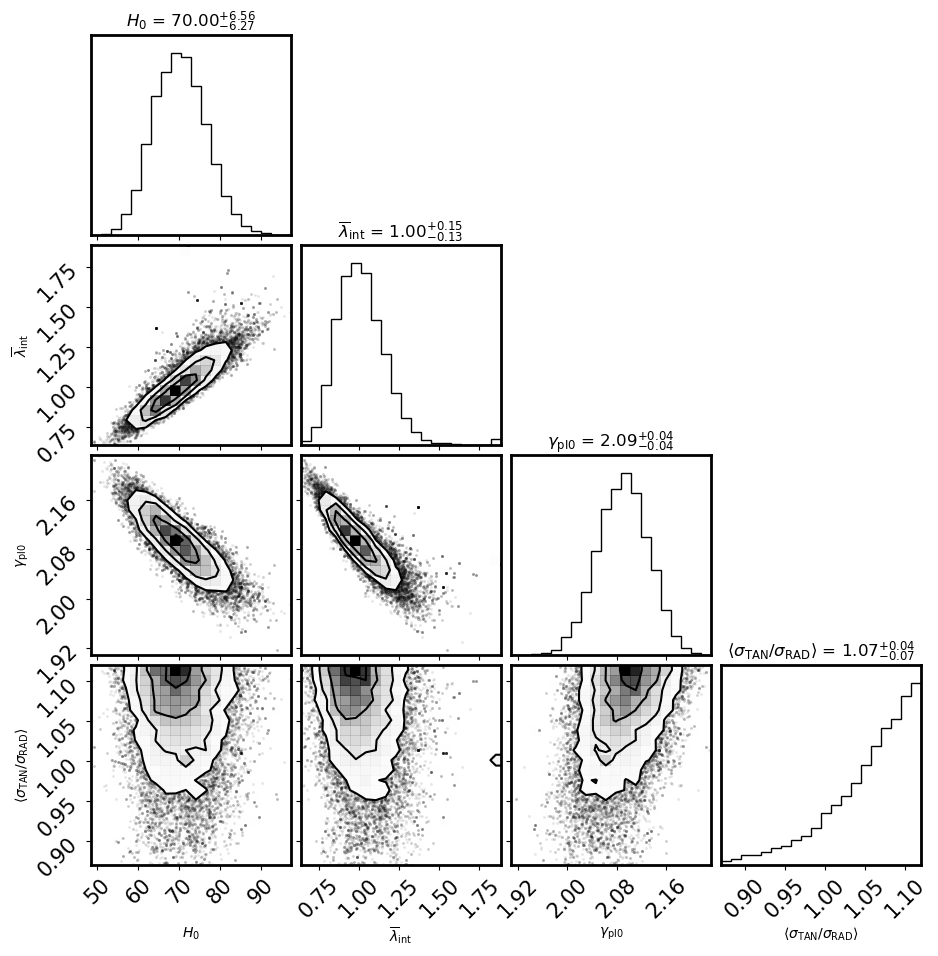

0.9482495991539139 reduced chi2


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [59:50<00:00,  4.49s/it]


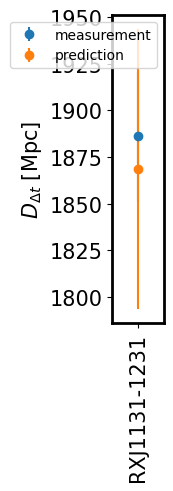

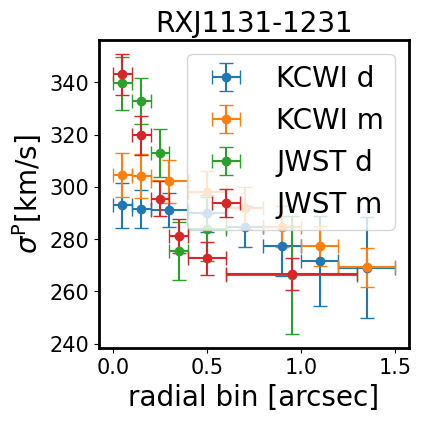

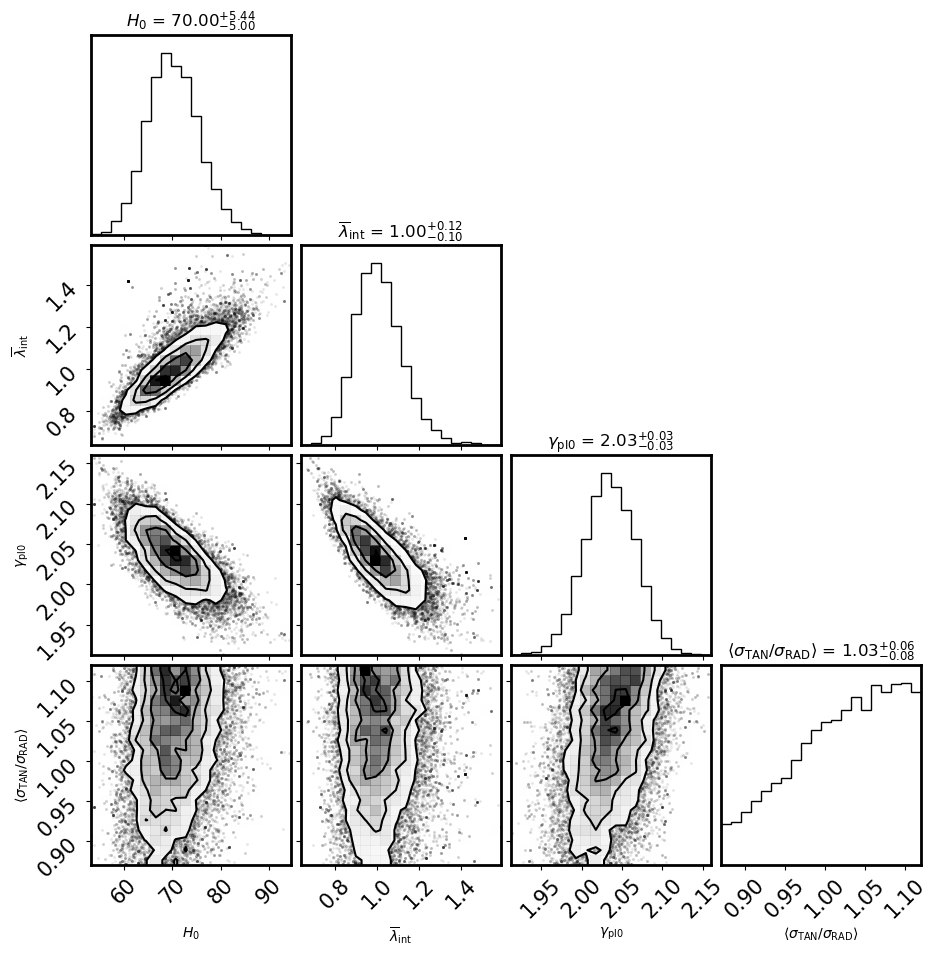

1.4079944878021002 reduced chi2


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [51:49<00:00,  3.89s/it]


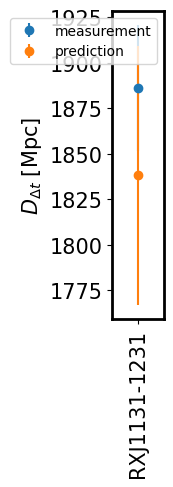

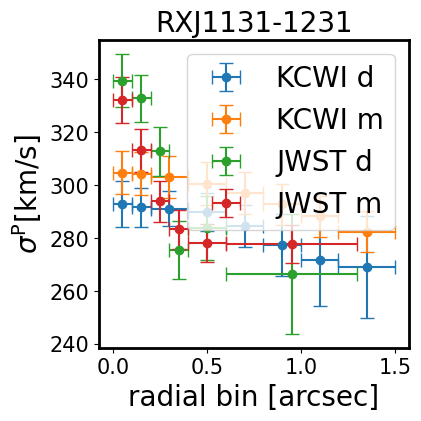

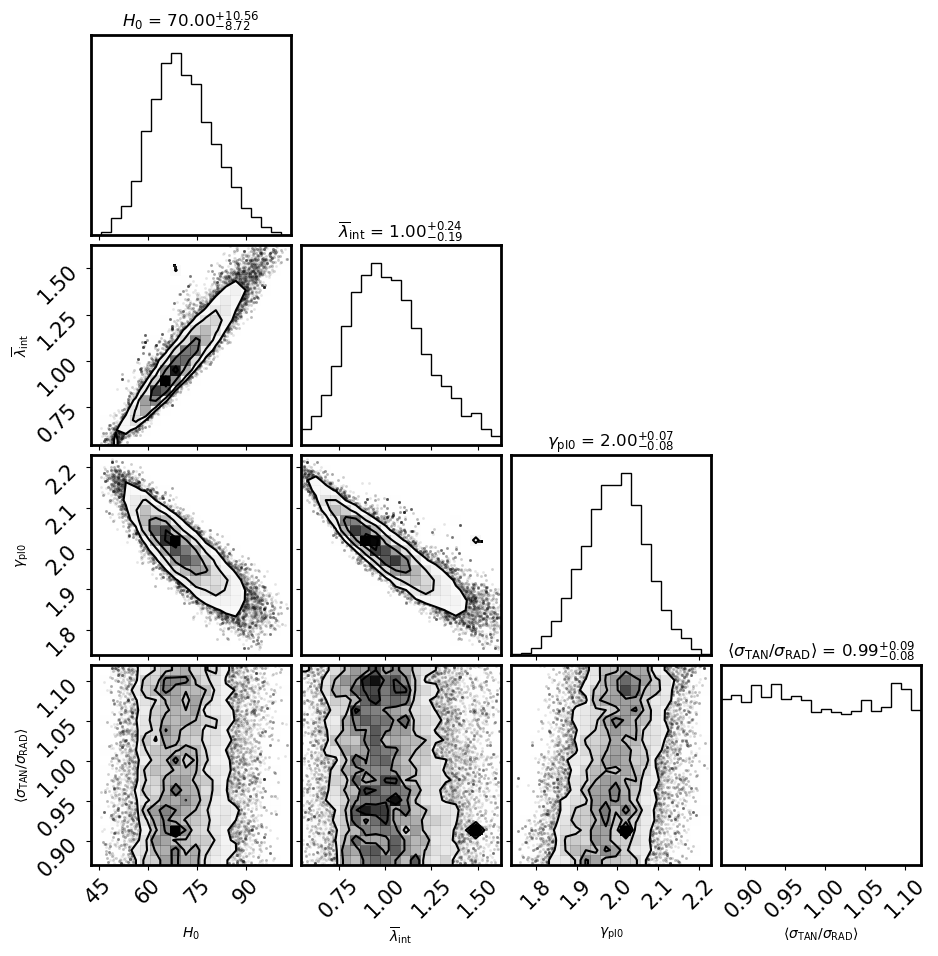

0.28559361103409947 reduced chi2


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [49:30<00:00,  3.71s/it]


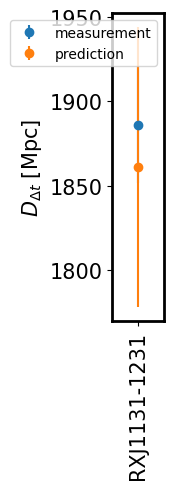

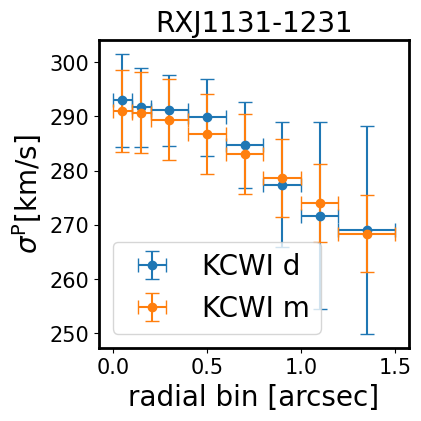

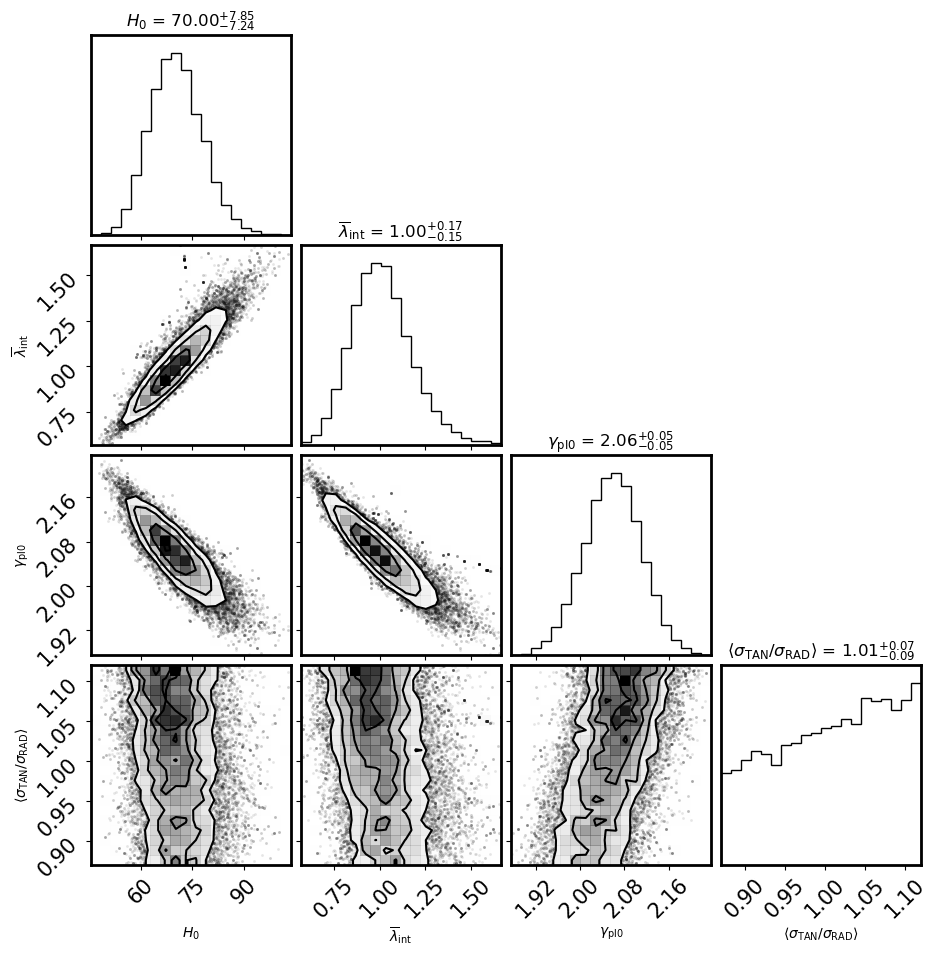

0.975633900508378 reduced chi2


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/249743055.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


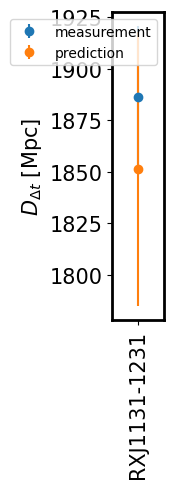

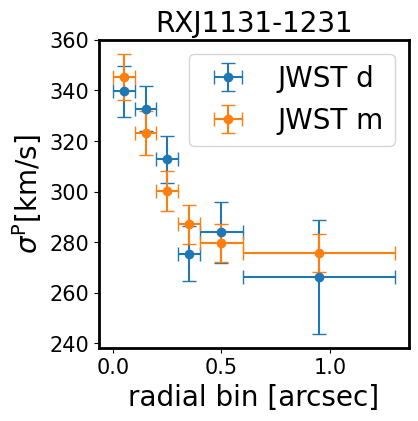

In [8]:
# here we sample the tdcosmo data with free lambda_mst  for each TDCOSMO lens individually
# this is for testing and reproducibility purpose only, as well as whether the data can be described by the model

from hierarc.Diagnostics.blinding import blind_posterior
from hierarc.Diagnostics.goodness_of_fit import GoodnessOfFit





def sample_posterior(posterior, lensing_prior=False, diagnostics=True, data_type='combined'):
    
    
    kwargs_model = {'lambda_mst_sampling': True, 'lambda_mst_distribution': 'NONE',
                      'anisotropy_sampling': True, 'los_sampling': False, 
                      'los_distributions': None, 'anisotropy_model': anisotropy_model, 
                      'anisotropy_parameterization': anisotropy_parameterization,
                      'anisotropy_distribution': 'NONE'}
        
    #tdcosmo_posterior_list[i]['kwargs_los_individual'] = None
    #tdcosmo_posterior_list[i]['los_distribution_individual'] = None
    posterior_copy = copy.deepcopy(posterior)
    if not lensing_prior:
        posterior_copy['prior_list'] = None
    mcmc_sampler_tdcosmo_single = MCMCSampler([posterior_copy], cosmology, 
                                                  kwargs_model,
                                                  kwargs_bounds,
                                                  custom_prior=None, interpolate_cosmo=False, 
                                                  num_redshift_interp=100, cosmo_fixed=None)

    mcmc_samples_tdcosmo_single, log_prob_single = mcmc_sampler_tdcosmo_single.mcmc_emcee(n_walkers, n_run, n_burn, kwargs_mean_start, kwargs_sigma_start)
    
    if diagnostics:
        # blind posterior
        posterior_blinded = blind_posterior(mcmc_samples_tdcosmo_single, mcmc_sampler_tdcosmo_single.param_names(latex_style=False))
        #posterior_blinded = mcmc_samples_tdcosmo_single
        corner.corner(posterior_blinded, show_titles=True, labels=mcmc_sampler_tdcosmo_single.param_names(latex_style=True))
        plt.show()

        # get best fit
        index_best_fit = np.where(log_prob_single == np.max(log_prob_single))
        kwargs_cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, _, kwargs_los_best_fit = mcmc_sampler_tdcosmo_single.param.args2kwargs(mcmc_samples_tdcosmo_single[index_best_fit[0][0]])
        cosmo_best_fit = mcmc_sampler_tdcosmo_single.param.cosmo(kwargs_cosmo_best_fit)

        # goodness of fit of kinematics
        gof = GoodnessOfFit([posterior_copy], kwargs_model=kwargs_model)

        f, ax = gof.plot_ddt_fit(cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, kwargs_los_best_fit,
                                     color_measurement=None, color_prediction=None, redshift_trend=False)
        f.show()

        # here we plot the IFU fit in case the data comes in this format
        # TODO: import bin edges (try to keep them saved) Current solution only works for one IFU product
        if data_type == 'combined':
            f, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                          kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_kcwi, measurement_indexes=np.arange(len(radial_bins_kcwi) - 1),
                          show_legend=True, data_label='KCWI d', model_label='KCWI m',
                                      color_measurement=None, color_prediction=None)

            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                          kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_jwst, measurement_indexes=np.arange(len(radial_bins_jwst) - 1) + len(radial_bins_kcwi)-1,
                          show_legend=True, data_label='JWST d', model_label='JWST m',
                                      color_measurement=None, color_prediction=None)

            f.show()
        elif data_type == 'KCWI':
            f, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                          kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_kcwi,
                          show_legend=True, data_label='KCWI d', model_label='KCWI m',
                                      color_measurement=None, color_prediction=None)
            f.show()
        elif data_type == 'JWST':
            f, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                          kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_jwst,
                          show_legend=True, data_label='JWST d', model_label='JWST m',
                                      color_measurement=None, color_prediction=None)
            f.show()

    return mcmc_samples_tdcosmo_single, mcmc_sampler_tdcosmo_single


mcmc_samples_list = []
label_name_list = ['JWST+KCWI', 'JWST+KCWI+lensing', 'KCWI', 'JWST']

data_type_list = ['combined', 'KCWI', 'JWST']

for i in range(len(posterior_list)):
    posterior = posterior_list[i]
    mcmc_samples_tdcosmo_single, mcmc_sampler_tdcosmo_single = sample_posterior(posterior, lensing_prior=False, diagnostics=True, data_type=data_type_list[i])
    mcmc_samples_list.append(mcmc_samples_tdcosmo_single)
    
    if i == 0:
        mcmc_samples_tdcosmo_single, mcmc_sampler_tdcosmo_single = sample_posterior(posterior, lensing_prior=True, diagnostics=True, data_type=data_type_list[i])
        mcmc_samples_list.append(mcmc_samples_tdcosmo_single)
        


/Users/sibirrer/opt/anaconda3/envs/hierarc_310/lib/python3.10/site-packages/corner/core.py:780: UserWarning: The following kwargs were not used by contour: 'color'
  ax.contourf(
/Users/sibirrer/opt/anaconda3/envs/hierarc_310/lib/python3.10/site-packages/corner/core.py:780: UserWarning: The following kwargs were not used by contour: 'color'
  ax.contourf(
/Users/sibirrer/opt/anaconda3/envs/hierarc_310/lib/python3.10/site-packages/corner/core.py:780: UserWarning: The following kwargs were not used by contour: 'color'
  ax.contourf(
/Users/sibirrer/opt/anaconda3/envs/hierarc_310/lib/python3.10/site-packages/corner/core.py:780: UserWarning: The following kwargs were not used by contour: 'color'
  ax.contourf(
/Users/sibirrer/opt/anaconda3/envs/hierarc_310/lib/python3.10/site-packages/corner/core.py:780: UserWarning: The following kwargs were not used by contour: 'color'
  ax.contourf(
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_91957/952071865.py:71: UserWarning: FigureCanv

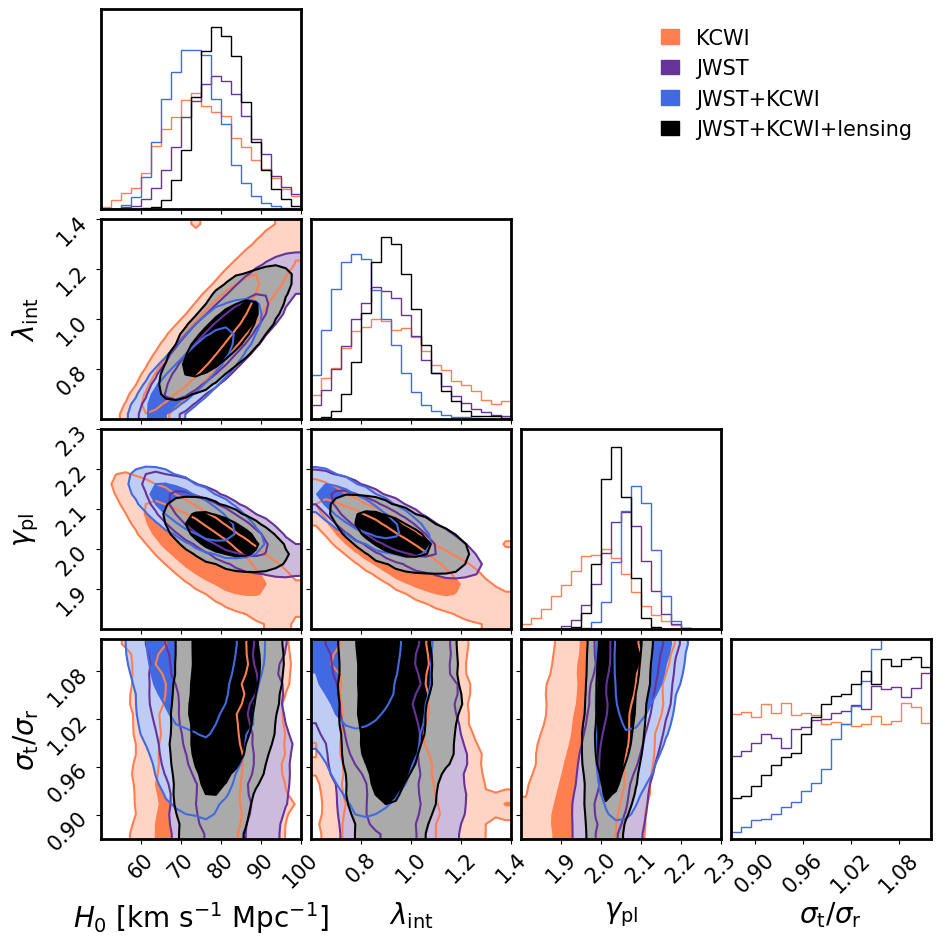

In [19]:
mcmc_samples_list_blinded = []

_H0_blind = np.mean(mcmc_samples_list[0][:, 0])
_lambda_blind = np.mean(mcmc_samples_list[0][:, 1])


for mcmc_samples in mcmc_samples_list:
    mcmc_samples_ = copy.deepcopy(mcmc_samples)
    #mcmc_samples_[:, 0] += (70 - _H0_blind)
    #mcmc_samples_[:, 1] += (1 - _lambda_blind)
    mcmc_samples_list_blinded.append(mcmc_samples_)
    
    

levels = [0.68, 0.95]
extents = [[50, 100], [0.6, 1.4], [1.8, 2.3] , [0.87, 1.12]]

index_list = [2, 3, 0, 1]


color_list = ['royalblue', 'k', 'coral', 'rebeccapurple', 'mediumvioletred', 'steelblue', 'crimson', 'g', 'purple', 'orange', 'r', 'k']


labels = mcmc_sampler_tdcosmo_single.param_names(latex_style=True)
# adopt parameter naming conventions
labels[0] = r'$H_{0}$ [km s$^{-1}$ Mpc$^{-1}$]'
labels[1] = r'$\lambda_{\rm int}$'
labels[2] = r'$\gamma_{\rm pl}$'
labels[3] = r'$\sigma_{\rm t}/\sigma_{\rm r}$'

kwargs_corner = {'bins': 20, 'alpha': 0.1, 'smooth': 0.8, 'smooth1d': None, 
                 'levels': levels, 
                 'fill_contours': True, 'plot_datapoints': False,
                 'range': extents,
                 'alpha': 0.2}

i_first = 2
fig = corner.corner(mcmc_samples_list_blinded[i_first],
                    labels=labels,
                    color=color_list[i_first],
                    hist_kwargs= {'density': True, 'color': color_list[i_first]},
                    title_kwargs=dict(fontsize=15),
                    label_kwargs=dict(fontsize=20),
                    contourf_kwargs={'color': color_list[i_first]},
                    **kwargs_corner
                   )
for i in index_list:
    if i == i_first:
        pass
    else:
        fig = corner.corner(mcmc_samples_list_blinded[i], color=color_list[i], fig=fig,
                            hist_kwargs= {'density': True, 'color': color_list[i]}, **kwargs_corner)



ax = fig.axes[3]
ax.set_visible(True)
ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)


handles = []
for i in index_list:
    patch = mpatches.Patch(color=color_list[i], label=label_name_list[i])
    handles.append(patch)


ax.legend(handles=handles, fontsize=15, handlelength=0.9, loc=1, frameon=False)
#fig.savefig('/Users/sibirrer/Science/Projects/TDCOSMO/Papers/Milestone25/rxj_1131_posterior.pdf')
fig.show()


